In [1]:
from scipy.io import loadmat
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib widget

In [2]:
fic_glodap = '/Users/chemon/ARGO_NEW/NEW_LOCODOX/locodox_python/data/GLODAPv2.2023_Merged_Master_File.mat'
data = loadmat(fic_glodap)

In [3]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

def latlon_to_xyz(lat, lon):
    """Convert lat/lon (deg) to 3D cartesian coordinates on unit sphere."""
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)
    return np.column_stack((x, y, z))

def match_glodap_to_ds(
    ds,
    mat,
    oxy_glodap="G2oxygen",
    pres_glodap="G2pressure",
    k=5,
    lat_name="LATITUDE",
    lon_name="LONGITUDE",
    time_name="JULD",

):
    """
    Match each profile in ds with closest GLODAP points based on spatial distance.
    Returns all values (oxy, pres) for the k closest points, handling variable k.
    
    Parameters
    ----------
    ds : xarray.Dataset
        The dataset containing the profiles to match.
    mat : dict (loaded .mat file)
        The GLODAP data.
    oxy_glodap : str
        Variable name in GLODAP file for oxygen.
    pres_glodap : str
        Variable name in GLODAP file for pressure.
    k : int
        Number of spatial neighbors to test (this is a maximum).
    lat_name, lon_name : str
        Names of the latitude and longitude variables in ds.
    
    Returns
    -------
    final_idx : list of arrays
        Indices of the closest GLODAP points for each profile in ds (variable length).
    matched_values_oxy : list of arrays
        Oxygen values for the closest GLODAP points (variable length).
    matched_values_pres : list of arrays
        Pressure values for the closest GLODAP points (variable length).
    spatial_dist_km : list of arrays
        Spatial distances (in km) to the closest GLODAP points (variable length).
    """
    
    earth_radius = 6371  # Radius of the Earth in kilometers
    
    # --- GLODAP coordinates (latitude, longitude)
    lat_g = np.array(mat["G2latitude"]).ravel()
    lon_g = np.array(mat["G2longitude"]).ravel()

    # Convert GLODAP coordinates to 3D Cartesian coordinates
    xyz_g = latlon_to_xyz(lat_g, lon_g)
    tree = cKDTree(xyz_g)

    # --- DS coordinates (latitude, longitude)
    lat_ds = ds[lat_name].values
    lon_ds = ds[lon_name].values
    xyz_ds = latlon_to_xyz(lat_ds, lon_ds)

    # --- Find the closest spatial neighbors
    spatial_dist, idx = tree.query(xyz_ds, k=k)

    # --- Extract matched variables (oxy and pres) from GLODAP
    var_g_oxy = np.array(mat[oxy_glodap]).ravel()
    var_g_pres = np.array(mat[pres_glodap]).ravel()

    # Date

    year  = np.array(mat["G2year"]).ravel()
    month = np.array(mat["G2month"]).ravel()
    day   = np.array(mat["G2day"]).ravel()

    date_g = pd.to_datetime(
        dict(year=year, month=month, day=day),
        errors="coerce"
    ).values

    # --- DS dates
    #date_ds = pd.to_datetime(ds[time_name].values)
    date_ds = ds[time_name].values
    #date_ds = date_ds[:, np.newaxis]

    # --- time difference
    #time_diff = np.abs(date_candidates - date_ds[:, None])

     # --- Store the matched values for all neighbors
    final_idx = []
    matched_values_oxy = []
    matched_values_pres = []
    spatial_dist_km = []
    time_diff_days = []

    for i in range(len(idx)):
        # Get indices of the k closest neighbors (may be fewer than k for some points)
        neighbors_idx = idx[i] if isinstance(idx[i], np.ndarray) else np.array([idx[i]])

        # For each profile, get the corresponding values of oxy and pres for the available neighbors
        oxy_vals = var_g_oxy[neighbors_idx]
        pres_vals = var_g_pres[neighbors_idx]
        dist_vals = spatial_dist[i][:len(neighbors_idx)]  # Handle fewer neighbors
        # Convert spatial distances to kilometers
        dist_vals_km = dist_vals * earth_radius

        date_candidates = date_g[neighbors_idx]
        time_diff = np.abs(date_ds[i] - date_candidates).astype('timedelta64[D]')
        
        # Store the results
        final_idx.append(neighbors_idx)
        matched_values_oxy.append(oxy_vals)
        matched_values_pres.append(pres_vals)
        spatial_dist_km.append(dist_vals_km)
        time_diff_days.append(time_diff)

    return final_idx, matched_values_oxy, matched_values_pres, spatial_dist_km, time_diff_days


In [4]:
fic_argo = '/Volumes/argo/gdac/dac/coriolis/6902882/6902882_Sprof.nc'
ds = xr.open_dataset(fic_argo,engine='argo')
final_idx, oxy_match, pres_match, dist_space,diff_days = match_glodap_to_ds(
    ds,
    data,
    oxy_glodap="G2oxygen",
    pres_glodap="G2pressure",
    k=10,
)

In [5]:
oxy_a_garder = []
pres_a_garder = []
for i in range(len(dist_space)):
    mask = (dist_space[i]<150) #& (diff_days[i]<700)
    oxy_a_garder.append(oxy_match[i][mask])
    pres_a_garder.append(pres_match[i][mask])
  
    

In [6]:
print(pres_match[0])
print(pres_a_garder[0])
print(ds['PRES'][0].values)
print(ds['DOXY'][0].values)

[ 502.4 1101.7  101.5  299.9  701.6  900.9 1601.9    6.9 1250.5 1250.4]
[ 502.4 1101.7  101.5  299.9  701.6  900.9 1601.9    6.9 1250.5 1250.4]
[17.8 18.1 24.  ...  nan  nan  nan]
[291.6703        nan 291.70462 ...       nan       nan       nan]


In [7]:
import glob
import argopy
liste_fic = glob.glob("/Users/chemon/ARGO_NEW/NEW_LOCODOX/locodox_python/fic_res_janvier2026/6902882_Corr6_Corr4/nc/*nc")
liste_fic.sort()
#ds_corr = xr.open_mfdataset(liste_fic)
#ds_corr = xr.open_mfdataset(liste_fic, concat_dim="N_PROF", combine='nested')
#ds_corr = xr.open_mfdataset(liste_fic, combine='by_coords')
datasets = []
# Lire chaque fichier NetCDF et ajouter à la liste
for file in liste_fic:
    # Ouvrir le fichier NetCDF
    ds_bid  = xr.open_dataset(file,engine='argo')
    datasets.append(ds_bid)

In [8]:
oxy_interp = []

for i in range(len(oxy_a_garder)):
  
    # Sélection de l’élément i
    data_oxy = ds['DOXY'][i].values
    data_pres = ds['PRES'][i].values
    mask = ~np.isnan(data_oxy)
    # Interpolation sur les nouvelles coordonnées
    data_oxy_interp = np.interp(pres_a_garder[i],data_pres[mask],data_oxy[mask])
    #print(data_oxy)
    #print(np.nanmin(data_pres),np.nanmax(data_pres))
    #print(pres_match[i])
    #print(data_oxy_interp)
    
    oxy_interp.append(data_oxy_interp)

oxy_adjusted_interp = []
i=-1
for ds_en_cours in datasets:
    i = i+1
    data_oxy = ds_en_cours['DOXY'].values
    data_pres = ds_en_cours['PRES'].values
    mask = ~np.isnan(data_oxy)
    # Interpolation sur les nouvelles coordonnées
    data_oxy_interp = np.interp(pres_a_garder[i],data_pres[mask],data_oxy[mask])
    #print(data_oxy)
    #print(np.nanmin(data_pres),np.nanmax(data_pres))
    #print(pres_match[i])
    #print(data_oxy_interp)
    
    oxy_adjusted_interp.append(data_oxy_interp)

    
#var_interp = np.array(var_interp, dtype=object)

In [9]:
print(pres_match[0])
print(ds['PRES'][0].values)
print(oxy_interp[0])
print(oxy_adjusted_interp[0])
print(len(oxy_interp),len(oxy_adjusted_interp))

[ 502.4 1101.7  101.5  299.9  701.6  900.9 1601.9    6.9 1250.5 1250.4]
[17.8 18.1 24.  ...  nan  nan  nan]
[257.85545797 265.24942017 286.09477149 277.2321259  253.9643676
 262.47115882 265.24942017 291.67028809 265.24942017 265.24942017]
[288.43841553 288.43841553 288.43841553 288.43841553 288.43841553
 288.43841553 288.43841553 288.43841553 288.43841553 288.43841553]
154 153


In [15]:
fig, ax = plt.subplots(1,2)

print(type(ax))
for i in range(len(oxy_a_garder)):
    _=ax[0].plot(ds['DOXY'][i],ds['PRES'][i],'.b')
    
for ds_en_cours in datasets:
        _=ax[0].plot(ds_en_cours['DOXY_ADJUSTED'],ds_en_cours['PRES'],'.g')

for i in range(len(oxy_a_garder)-1):
    _=ax[0].plot(oxy_a_garder[i],pres_a_garder[i],'.r')
    _=ax[1].plot(oxy_interp[i]-oxy_a_garder[i],'.b')
    _=ax[1].plot(oxy_adjusted_interp[i]-oxy_a_garder[i],'.r')
    
    
ax[0].grid()
ax[0].invert_yaxis()

<class 'numpy.ndarray'>


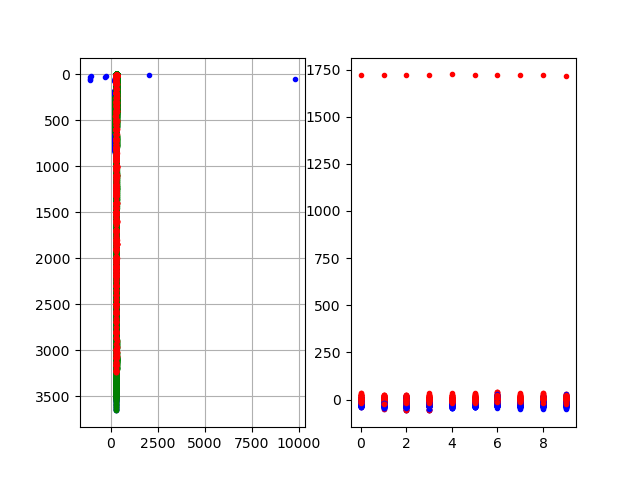

In [16]:
plt.show()




def latlon_to_xyz(lat, lon):
    """Convert lat/lon (deg) to 3D cartesian coordinates on unit sphere."""
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)
    return np.column_stack((x, y, z))


def match_glodap_to_ds(
    ds,
    mat,
    oxy_glodap="G2oxygen",
    pres_glodap="G2pressure",
    k=5,
    max_days=None,
    lat_name="LATITUDE",
    lon_name="LONGITUDE",
    time_name="JULD",
):
    """
    Match each profile in ds with closest GLODAP point (space + time).

    Parameters
    ----------
    ds : xarray.Dataset
    mat : dict (loaded .mat file)
    var_glodap : str
        Variable name in GLODAP file
    k : int
        Number of spatial neighbours to test
    max_days : int or None
        Maximum allowed time difference (days)
    lat_name, lon_name, time_name : str
        Names in ds

    Returns
    -------
    final_idx : array
    matched_values : array
    spatial_dist : array
    time_diff_days : array
    """

    earth_radius = 6371

    # --- GLODAP coordinates
    lat_g = np.array(mat["G2latitude"]).ravel()
    lon_g = np.array(mat["G2longitude"]).ravel()

    xyz_g = latlon_to_xyz(lat_g, lon_g)
    tree = cKDTree(xyz_g)

    # --- DS coordinates
    lat_ds = ds[lat_name].values
    lon_ds = ds[lon_name].values
    xyz_ds = latlon_to_xyz(lat_ds, lon_ds)

    # --- spatial nearest neighbours
    spatial_dist, idx = tree.query(xyz_ds, k=k)

    #print(spatial_dist,idx)

    # --- GLODAP dates
    year  = np.array(mat["G2year"]).ravel()
    month = np.array(mat["G2month"]).ravel()
    day   = np.array(mat["G2day"]).ravel()

    date_g = pd.to_datetime(
        dict(year=year, month=month, day=day),
        errors="coerce"
    ).values

    # --- DS dates
    #date_ds = pd.to_datetime(ds[time_name].values)
    date_ds = ds[time_name].values
    date_ds = date_ds[:, np.newaxis]
    # --- candidate dates
    date_candidates = date_g[idx]

    # --- time difference
    #time_diff = np.abs(date_candidates - date_ds[:, None])
    time_diff = np.abs(date_candidates - date_ds)


    #best_time_idx = np.argmin(time_diff, axis=1)
    best_time_idx = np.where(time_diff == np.min(time_diff, axis=1, keepdims=True))[1]
    print(best_time_idx)

    final_idx = idx[np.arange(len(idx)), best_time_idx]

    best_time_diff = time_diff[np.arange(len(idx)), best_time_idx]

    # --- Apply time threshold if requested
    if max_days is not None:
        valid = best_time_diff <= np.timedelta64(max_days, "D")
        final_idx[~valid] = -1

    # --- Extract matched variable
    var_g = np.array(mat[oxy_glodap]).ravel()

    matched_values_oxy = np.full(len(final_idx), np.nan)
    valid = final_idx >= 0
    matched_values_oxy[valid] = var_g[final_idx[valid]]

    var_g = np.array(mat[pres_glodap]).ravel()

    matched_values_pres = np.full(len(final_idx), np.nan)
    valid = final_idx >= 0
    matched_values_pres[valid] = var_g[final_idx[valid]]

    # Convert time difference to days (float)
    time_diff_days = best_time_diff / np.timedelta64(1, "D")


    return final_idx, matched_values_oxy,matched_values_pres, spatial_dist[:, 0]*earth_radius, time_diff_days
